# 32 - TCGA-BRCA Baseline VAE Training

This notebook:
1. Train baseline VAE on TCGA-BRCA (978 genes, VST-normalized)
2. Train retrain model (exclude structured forget set)
3. Create matched negatives via k-NN in latent space
4. Train fresh MIA attacker and evaluate baseline + retrain AUC

**Architecture:** Same as PBMC/Tabula Muris (likelihood='nb', softmax output, MSE loss).
Input dim changes from 2000 to 978.

**Dependencies:** `data/tcga_brca/tcga_brca_processed.h5ad`, `outputs/tcga_brca/split_structured.json`

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import json
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score

from utils import set_global_seed, GLOBAL_SEED, DEVICE, Timer
from vae import VAE, vae_loss
from train import create_dataloader, train_epoch, get_kl_weight
from attacker import MLPAttacker, extract_vae_features, build_attack_features

set_global_seed(GLOBAL_SEED)

DATA_DIR = Path('../data/tcga_brca')
OUTPUT_DIR = Path('../outputs/tcga_brca/baseline')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Seed: {GLOBAL_SEED}')
print(f'Device: {DEVICE}')

2026-03-28 09:29:50.485836: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Seed: 42
Device: cpu


## Load Data and Splits

In [2]:
adata = sc.read_h5ad(DATA_DIR / 'tcga_brca_processed.h5ad')
print(f'Data: {adata.shape}')

with open('../outputs/tcga_brca/split_structured.json') as f:
    split = json.load(f)

forget_indices = split['forget_indices']
retain_indices = split['retain_indices']
unseen_indices = split['unseen_indices']
train_all = forget_indices + retain_indices

print(f'Train: {len(train_all)} (forget={len(forget_indices)}, retain={len(retain_indices)})')
print(f'Unseen: {len(unseen_indices)}')

Data: (1089, 978)
Train: 925 (forget=158, retain=767)
Unseen: 164


## Train Baseline VAE

In [3]:
config = {
    'input_dim': adata.n_vars,
    'hidden_dims': [1024, 512, 128],
    'latent_dim': 32,
    'likelihood': 'nb',
    'dropout': 0.1,
    'use_layer_norm': True,
    'lr': 1e-4,
    'epochs': 100,
    'batch_size': 128,
    'kl_warmup_epochs': 20,
    'free_bits': 0.03,
    'early_stopping_patience': 15,
    'seed': GLOBAL_SEED
}

set_global_seed(GLOBAL_SEED)
model = VAE(
    input_dim=config['input_dim'],
    hidden_dims=config['hidden_dims'],
    latent_dim=config['latent_dim'],
    likelihood=config['likelihood'],
    dropout=config['dropout'],
    use_layer_norm=config['use_layer_norm']
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')
print(f'Architecture: {config["input_dim"]} -> {config["hidden_dims"]} -> z={config["latent_dim"]}')

Parameters: 4,208,356
Architecture: 978 -> [1024, 512, 128] -> z=32


In [4]:
train_loader = create_dataloader(adata, train_all, batch_size=config['batch_size'], shuffle=True)
print(f'Train batches: {len(train_loader)}')

optimizer = optim.Adam(model.parameters(), lr=config['lr'])

history = {'train_loss': [], 'train_recon': [], 'train_kl': [], 'kl_weight': []}
best_loss = float('inf')
patience_counter = 0
n_genes = config['input_dim']

print(f'Training for up to {config["epochs"]} epochs')
print(f'KL warmup: {config["kl_warmup_epochs"]} epochs, free bits: {config["free_bits"]}\n')

with Timer('Training'):
    for epoch in range(config['epochs']):
        kl_weight = get_kl_weight(epoch, config['kl_warmup_epochs'])
        metrics = train_epoch(
            model, train_loader, optimizer, DEVICE,
            likelihood=config['likelihood'],
            beta=kl_weight,
            free_bits=config['free_bits']
        )
        history['train_loss'].append(metrics['loss'])
        history['train_recon'].append(metrics['recon'])
        history['train_kl'].append(metrics['kl'])
        history['kl_weight'].append(kl_weight)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d}/{config["epochs"]} | '
                  f'Loss: {metrics["loss"]:.1f} ({metrics["loss"]/n_genes:.3f}/gene) | '
                  f'KL weight: {kl_weight:.2f}')
        
        if metrics['loss'] < best_loss:
            best_loss = metrics['loss']
            patience_counter = 0
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': metrics['loss'],
                'config': config
            }
            torch.save(checkpoint, OUTPUT_DIR / 'best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= config['early_stopping_patience']:
                print(f'\nEarly stopping at epoch {epoch+1}')
                break

print(f'\nBest loss: {best_loss:.2f} ({best_loss/n_genes:.3f}/gene)')
print(f'Stopped at epoch {len(history["train_loss"])}')

Train batches: 8


Training for up to 100 epochs
KL warmup: 20 epochs, free bits: 0.03

[Training] Starting at 09:29:56


Epoch  10/100 | Loss: 3259.9 (3.333/gene) | KL weight: 0.45


Epoch  20/100 | Loss: 2240.2 (2.291/gene) | KL weight: 0.95


Epoch  30/100 | Loss: 1792.6 (1.833/gene) | KL weight: 1.00


...

Epoch  60/100 | Loss: 1322.8 (1.353/gene) | KL weight: 1.00


Epoch  70/100 | Loss: 1242.0 (1.270/gene) | KL weight: 1.00


Epoch  80/100 | Loss: 1162.4 (1.189/gene) | KL weight: 1.00


Epoch  90/100 | Loss: 1101.2 (1.126/gene) | KL weight: 1.00


Epoch 100/100 | Loss: 1055.2 (1.079/gene) | KL weight: 1.00
[Training] Completed in 27.95 seconds

Best loss: 1055.19 (1.079/gene)
Stopped at epoch 100


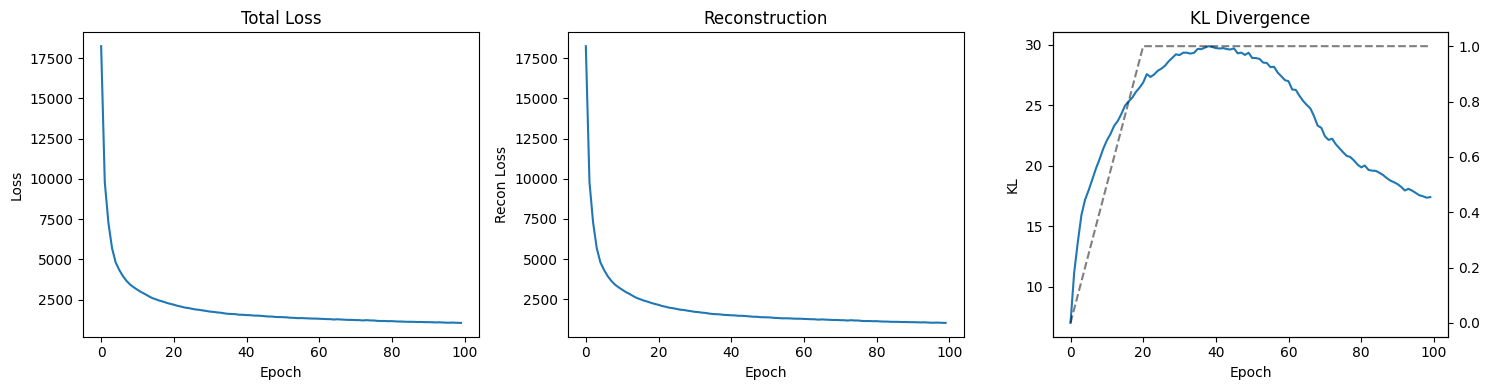

In [5]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Total Loss')
axes[1].plot(history['train_recon'])
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Recon Loss'); axes[1].set_title('Reconstruction')
axes[2].plot(history['train_kl'], label='KL')
ax2 = axes[2].twinx()
ax2.plot(history['kl_weight'], 'k--', alpha=0.5, label='weight')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('KL'); axes[2].set_title('KL Divergence')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Latent Space Visualization

Latent embeddings: (1089, 32)


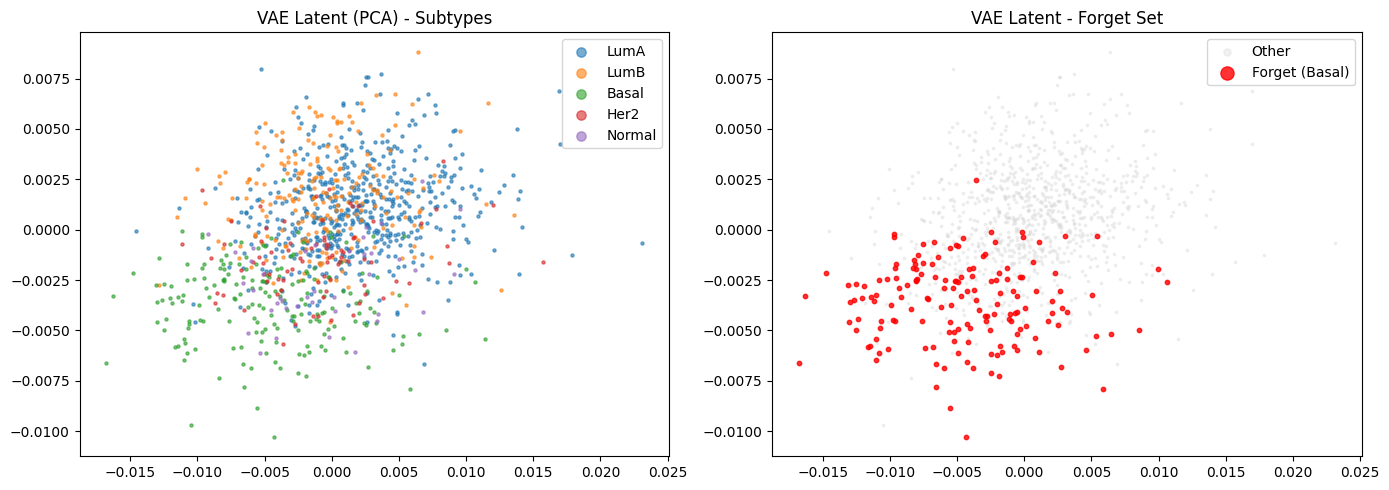

In [6]:
# Load best model
checkpoint = torch.load(OUTPUT_DIR / 'best_model.pt', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Encode all samples
X = adata.X
if hasattr(X, 'toarray'):
    X = X.toarray()
x_tensor = torch.FloatTensor(X).to(DEVICE)

with torch.no_grad():
    mu, logvar = model.encode(x_tensor)
    z_all = mu.cpu().numpy()

print(f'Latent embeddings: {z_all.shape}')

# PCA of latent space
pca = PCA(n_components=2)
z_pca = pca.fit_transform(z_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

subtypes = adata.obs['subtype'].values
for st in ['LumA', 'LumB', 'Basal', 'Her2', 'Normal']:
    mask = subtypes == st
    axes[0].scatter(z_pca[mask, 0], z_pca[mask, 1], s=5, alpha=0.6, label=st)
axes[0].legend(markerscale=3)
axes[0].set_title('VAE Latent (PCA) - Subtypes')

forget_mask = np.zeros(adata.n_obs, dtype=bool)
forget_mask[forget_indices] = True
axes[1].scatter(z_pca[~forget_mask, 0], z_pca[~forget_mask, 1], c='lightgray', s=3, alpha=0.3, label='Other')
axes[1].scatter(z_pca[forget_mask, 0], z_pca[forget_mask, 1], c='red', s=10, alpha=0.8, label='Forget (Basal)')
axes[1].legend(markerscale=3)
axes[1].set_title('VAE Latent - Forget Set')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'latent_space.png', dpi=150, bbox_inches='tight')
plt.show()

## Train Retrain Model

Retrain from scratch on retain set only (excluding Basal forget set).

In [7]:
RETRAIN_DIR = Path('../outputs/tcga_brca/retrain_structured')
RETRAIN_DIR.mkdir(parents=True, exist_ok=True)

set_global_seed(GLOBAL_SEED)
retrain_model = VAE(
    input_dim=config['input_dim'],
    hidden_dims=config['hidden_dims'],
    latent_dim=config['latent_dim'],
    likelihood=config['likelihood'],
    dropout=config['dropout'],
    use_layer_norm=config['use_layer_norm']
).to(DEVICE)

retrain_loader = create_dataloader(adata, retain_indices, batch_size=config['batch_size'], shuffle=True)
retrain_optimizer = optim.Adam(retrain_model.parameters(), lr=config['lr'])

print(f'Retraining on {len(retain_indices)} samples (excluding {len(forget_indices)} Basal)')
best_retrain_loss = float('inf')
patience_counter = 0

with Timer('Retrain'):
    for epoch in range(config['epochs']):
        kl_weight = get_kl_weight(epoch, config['kl_warmup_epochs'])
        metrics = train_epoch(
            retrain_model, retrain_loader, retrain_optimizer, DEVICE,
            likelihood=config['likelihood'], beta=kl_weight, free_bits=config['free_bits']
        )
        if (epoch + 1) % 20 == 0:
            print(f'Epoch {epoch+1}/{config["epochs"]} | Loss: {metrics["loss"]:.1f}')
        if metrics['loss'] < best_retrain_loss:
            best_retrain_loss = metrics['loss']
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': retrain_model.state_dict(),
                'config': config,
                'train_loss': metrics['loss']
            }, RETRAIN_DIR / 'best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= config['early_stopping_patience']:
                print(f'Early stopping at epoch {epoch+1}')
                break

print(f'\nBest retrain loss: {best_retrain_loss:.2f}')

Retraining on 767 samples (excluding 158 Basal)
[Retrain] Starting at 09:30:26


Epoch 20/100 | Loss: 2492.6


Epoch 40/100 | Loss: 1676.3


Epoch 60/100 | Loss: 1377.2


Epoch 80/100 | Loss: 1206.4


Epoch 100/100 | Loss: 1077.8
[Retrain] Completed in 18.69 seconds

Best retrain loss: 1077.81


## Create Matched Negatives

In [8]:
# Use baseline model latent space for k-NN matching
forget_z = z_all[forget_indices]
unseen_z = z_all[unseen_indices]

K = 10
nbrs = NearestNeighbors(n_neighbors=K, algorithm='ball_tree').fit(unseen_z)
distances, knn_indices = nbrs.kneighbors(forget_z)

matched_local = np.unique(knn_indices.flatten())
matched_indices = [int(unseen_indices[i]) for i in matched_local]

mean_dist = float(distances.mean())
median_dist = float(np.median(distances))

print(f'Matched negatives: {len(matched_indices)} cells')
print(f'Mean k-NN distance: {mean_dist:.4f}')
print(f'Median k-NN distance: {median_dist:.4f}')

MATCHED_DIR = Path('../outputs/tcga_brca')
matched_data = {
    'matched_indices': matched_indices,
    'method': 'latent_knn',
    'k': K,
    'mean_distance': mean_dist,
    'median_distance': median_dist,
    'n_forget': len(forget_indices),
    'n_matched': len(matched_indices)
}
with open(MATCHED_DIR / 'matched_negatives.json', 'w') as f:
    json.dump(matched_data, f, indent=2)
print(f'Saved matched_negatives.json')

Matched negatives: 121 cells
Mean k-NN distance: 0.0086
Median k-NN distance: 0.0084
Saved matched_negatives.json


## MIA Evaluation

Train fresh attacker on baseline model features (forget vs matched negatives),
then evaluate both baseline and retrain models.

In [9]:
def extract_features_for_indices(vae_model, adata, indices, device):
    """Extract MIA features for a set of indices."""
    X = adata.X[indices]
    if hasattr(X, 'toarray'):
        X = X.toarray()
    x = torch.FloatTensor(X).to(device)
    lib = x.sum(dim=1, keepdim=True)
    vae_feats = extract_vae_features(vae_model, x, lib, device, requires_grad=False)
    return build_attack_features(vae_feats, variant='v1')


def train_fresh_attacker(pos_feats, neg_feats, device, epochs=100, lr=1e-3):
    """Train a fresh MIA attacker."""
    input_dim = pos_feats.shape[1]
    attacker = MLPAttacker(input_dim, [256, 256], dropout=0.3, use_spectral_norm=True).to(device)
    opt = optim.Adam(attacker.parameters(), lr=lr, weight_decay=1e-4)
    
    X = torch.cat([pos_feats, neg_feats]).to(device)
    y = torch.cat([torch.ones(len(pos_feats)), torch.zeros(len(neg_feats))]).unsqueeze(1).to(device)
    
    for epoch in range(epochs):
        attacker.train()
        opt.zero_grad()
        logits = attacker(X)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y)
        loss.backward()
        opt.step()
    
    attacker.eval()
    return attacker


def compute_auc(attacker, pos_feats, neg_feats, device):
    """Compute AUC."""
    X = torch.cat([pos_feats, neg_feats]).to(device)
    y = np.concatenate([np.ones(len(pos_feats)), np.zeros(len(neg_feats))])
    with torch.no_grad():
        preds = torch.sigmoid(attacker(X)).cpu().numpy().flatten()
    return float(roc_auc_score(y, preds))


print(f'Feature dim for z=32: {2*32+5}')

Feature dim for z=32: 69


In [10]:
# Extract features from BASELINE model
print('Extracting features from baseline model...')
baseline_forget_feats = extract_features_for_indices(model, adata, forget_indices, DEVICE)
baseline_matched_feats = extract_features_for_indices(model, adata, matched_indices, DEVICE)
print(f'Forget features: {baseline_forget_feats.shape}')
print(f'Matched features: {baseline_matched_feats.shape}')

# Train fresh attacker
print('\nTraining fresh attacker...')
attacker = train_fresh_attacker(baseline_forget_feats, baseline_matched_feats, DEVICE)

# Evaluate baseline
baseline_auc = compute_auc(attacker, baseline_forget_feats, baseline_matched_feats, DEVICE)
baseline_advantage = 2 * abs(baseline_auc - 0.5)
print(f'\nBaseline AUC: {baseline_auc:.3f}')
print(f'Baseline advantage: {baseline_advantage:.3f}')

Extracting features from baseline model...
Forget features: torch.Size([158, 69])
Matched features: torch.Size([121, 69])

Training fresh attacker...



Baseline AUC: 0.821
Baseline advantage: 0.641


In [11]:
# Evaluate RETRAIN model
retrain_ckpt = torch.load(RETRAIN_DIR / 'best_model.pt', map_location=DEVICE)
retrain_model.load_state_dict(retrain_ckpt['model_state_dict'])
retrain_model.eval()

print('Extracting features from retrain model...')
retrain_forget_feats = extract_features_for_indices(retrain_model, adata, forget_indices, DEVICE)
retrain_matched_feats = extract_features_for_indices(retrain_model, adata, matched_indices, DEVICE)

# Train a SEPARATE fresh attacker for retrain (fair comparison)
print('Training fresh attacker for retrain...')
retrain_attacker = train_fresh_attacker(retrain_forget_feats, retrain_matched_feats, DEVICE)
retrain_auc = compute_auc(retrain_attacker, retrain_forget_feats, retrain_matched_feats, DEVICE)
retrain_advantage = 2 * abs(retrain_auc - 0.5)

print(f'\nRetrain AUC: {retrain_auc:.3f}')
print(f'Retrain advantage: {retrain_advantage:.3f}')

Extracting features from retrain model...
Training fresh attacker for retrain...



Retrain AUC: 0.860
Retrain advantage: 0.719


In [12]:
# Save results
results = {
    'dataset': 'TCGA-BRCA',
    'n_samples': int(adata.n_obs),
    'n_genes': int(adata.n_vars),
    'n_train': len(train_all),
    'n_forget': len(forget_indices),
    'n_retain': len(retain_indices),
    'n_unseen': len(unseen_indices),
    'n_matched': len(matched_indices),
    'forget_subtype': 'Basal',
    'baseline': {
        'auc': baseline_auc,
        'advantage': baseline_advantage,
        'train_loss': float(best_loss),
        'epochs': len(history['train_loss']),
    },
    'retrain': {
        'auc': retrain_auc,
        'advantage': retrain_advantage,
        'train_loss': float(best_retrain_loss),
    },
    'config': config,
    'n_params': n_params,
}

with open('../outputs/tcga_brca/baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('\n' + '='*50)
print('TCGA-BRCA Baseline Results')
print('='*50)
print(f'Samples: {results["n_samples"]} ({results["n_genes"]} genes)')
print(f'Parameters: {n_params:,}')
print(f'Forget set: {results["n_forget"]} Basal patients')
print(f'Matched negatives: {results["n_matched"]}')
print(f'\nBaseline AUC:  {baseline_auc:.3f} (advantage: {baseline_advantage:.3f})')
print(f'Retrain AUC:   {retrain_auc:.3f} (advantage: {retrain_advantage:.3f})')
print(f'\nSaved baseline_results.json')


TCGA-BRCA Baseline Results
Samples: 1089 (978 genes)
Parameters: 4,208,356
Forget set: 158 Basal patients
Matched negatives: 121

Baseline AUC:  0.821 (advantage: 0.641)
Retrain AUC:   0.860 (advantage: 0.719)

Saved baseline_results.json


## Summary

| Output | Path |
|--------|------|
| Baseline checkpoint | `outputs/tcga_brca/baseline/best_model.pt` |
| Retrain checkpoint | `outputs/tcga_brca/retrain_structured/best_model.pt` |
| Training curves | `outputs/tcga_brca/baseline/training_curves.png` |
| Latent space | `outputs/tcga_brca/baseline/latent_space.png` |
| Matched negatives | `outputs/tcga_brca/matched_negatives.json` |
| Baseline results | `outputs/tcga_brca/baseline_results.json` |

**Next:** `33_tcga_brca_unlearning.ipynb` - Run unlearning methods on TCGA-BRCA